In [32]:
# =========================================================
# PART 1 — IMPORT LIBRARIES
# This section installs any missing libraries and then imports
# all libraries needed for loading data, cleaning data,
# visualization, preprocessing, PCA, ICA, and transform demos.
# =========================================================

import sys
!{sys.executable} -m pip install PyWavelets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA, FastICA
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from scipy.signal import butter, filtfilt
from scipy.fft import fft, fftfreq
import pywt
from IPython.display import Audio, display

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [33]:
# =========================================================
# PART 2 — LOAD DATASET AND INSPECT IT
# This section loads the CSV file and checks the first rows,
# shape, column names, info, and missing values.
# Split here if you want section 2 to start.
# =========================================================

df = pd.read_csv("students_ai_usage.csv")

print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

First 5 rows:
   age education_level  study_hours_per_day uses_ai ai_tools_used  \
0   19         college                  1.4      No           NaN   
1   15          school                  3.9     Yes       Copilot   
2   15          school                  1.9     Yes       Copilot   
3   15          school                  2.8      No           NaN   
4   19         college                  2.7      No           NaN   

  purpose_of_ai  grades_before_ai  grades_after_ai  daily_screen_time_hours  
0           NaN                62               62                        3  
1      Research                56               61                        2  
2      Homework                75               88                        5  
3           NaN                55               55                        3  
4           NaN                59               59                        3  

Shape of dataset:
(100, 9)

Column names:
['age', 'education_level', 'study_hours_per_day', 'uses_ai',

In [34]:
# =========================================================
# PART 3 — CLEAN DATA
# This section removes extra spaces from column names and
# text columns so categories are clean and consistent.
# Split here if you want section 3 to start.
# =========================================================

df.columns = df.columns.str.strip()

text_cols = ["education_level", "uses_ai", "ai_tools_used", "purpose_of_ai"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

print("\nCleaned data preview:")
print(df.head())

print("\nUnique values in text columns:")
for col in text_cols:
    print(f"{col}: {df[col].unique()}")


Cleaned data preview:
   age education_level  study_hours_per_day uses_ai ai_tools_used  \
0   19         college                  1.4      No           nan   
1   15          school                  3.9     Yes       Copilot   
2   15          school                  1.9     Yes       Copilot   
3   15          school                  2.8      No           nan   
4   19         college                  2.7      No           nan   

  purpose_of_ai  grades_before_ai  grades_after_ai  daily_screen_time_hours  
0           nan                62               62                        3  
1      Research                56               61                        2  
2      Homework                75               88                        5  
3           nan                55               55                        3  
4           nan                59               59                        3  

Unique values in text columns:
education_level: ['college' 'school']
uses_ai: ['No' 'Yes']
ai

In [35]:
# =========================================================
# PART 4 — FEATURE ENGINEERING
# This section creates useful new variables:
# 1) grade_improvement = grades_after_ai - grades_before_ai
# 2) uses_ai_binary = Yes/No converted to 1/0
# Split here if you want section 4 to start.
# =========================================================

df["grade_improvement"] = df["grades_after_ai"] - df["grades_before_ai"]
df["uses_ai_binary"] = df["uses_ai"].map({"Yes": 1, "No": 0})

print("\nPreview of new variables:")
print(df[["grades_before_ai", "grades_after_ai", "grade_improvement", "uses_ai", "uses_ai_binary"]].head())

print("\nSummary of new variables:")
print(df[["grade_improvement", "uses_ai_binary"]].describe())


Preview of new variables:
   grades_before_ai  grades_after_ai  grade_improvement uses_ai  \
0                62               62                  0      No   
1                56               61                  5     Yes   
2                75               88                 13     Yes   
3                55               55                  0      No   
4                59               59                  0      No   

   uses_ai_binary  
0               0  
1               1  
2               1  
3               0  
4               0  

Summary of new variables:
       grade_improvement  uses_ai_binary
count         100.000000      100.000000
mean            3.930000        0.400000
std             5.326236        0.492366
min             0.000000        0.000000
25%             0.000000        0.000000
50%             0.000000        0.000000
75%             8.000000        1.000000
max            15.000000        1.000000


In [36]:
# =========================================================
# PART 5 — DESCRIPTIVE STATISTICS
# This section summarizes numeric columns and prints
# category counts for the main text columns.
# Split here if you want section 5 to start.
# =========================================================

numeric_cols = [
    "age",
    "study_hours_per_day",
    "grades_before_ai",
    "grades_after_ai",
    "daily_screen_time_hours",
    "grade_improvement"
]

print("\nNumeric summary statistics:")
print(df[numeric_cols].describe())

print("\nCategorical value counts:")
for col in ["education_level", "uses_ai", "ai_tools_used", "purpose_of_ai"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


Numeric summary statistics:
              age  study_hours_per_day  grades_before_ai  grades_after_ai  \
count  100.000000           100.000000         100.00000       100.000000   
mean    16.490000             2.987000          64.77000        68.700000   
std      1.702612             1.145713           6.16909         8.140806   
min     14.000000             1.000000          55.00000        55.000000   
25%     15.000000             1.975000          59.00000        61.000000   
50%     16.000000             2.800000          63.00000        69.000000   
75%     18.000000             4.025000          70.00000        74.000000   
max     19.000000             5.000000          75.00000        89.000000   

       daily_screen_time_hours  grade_improvement  
count               100.000000         100.000000  
mean                  4.340000           3.930000  
std                   1.793479           5.326236  
min                   2.000000           0.000000  
25%              

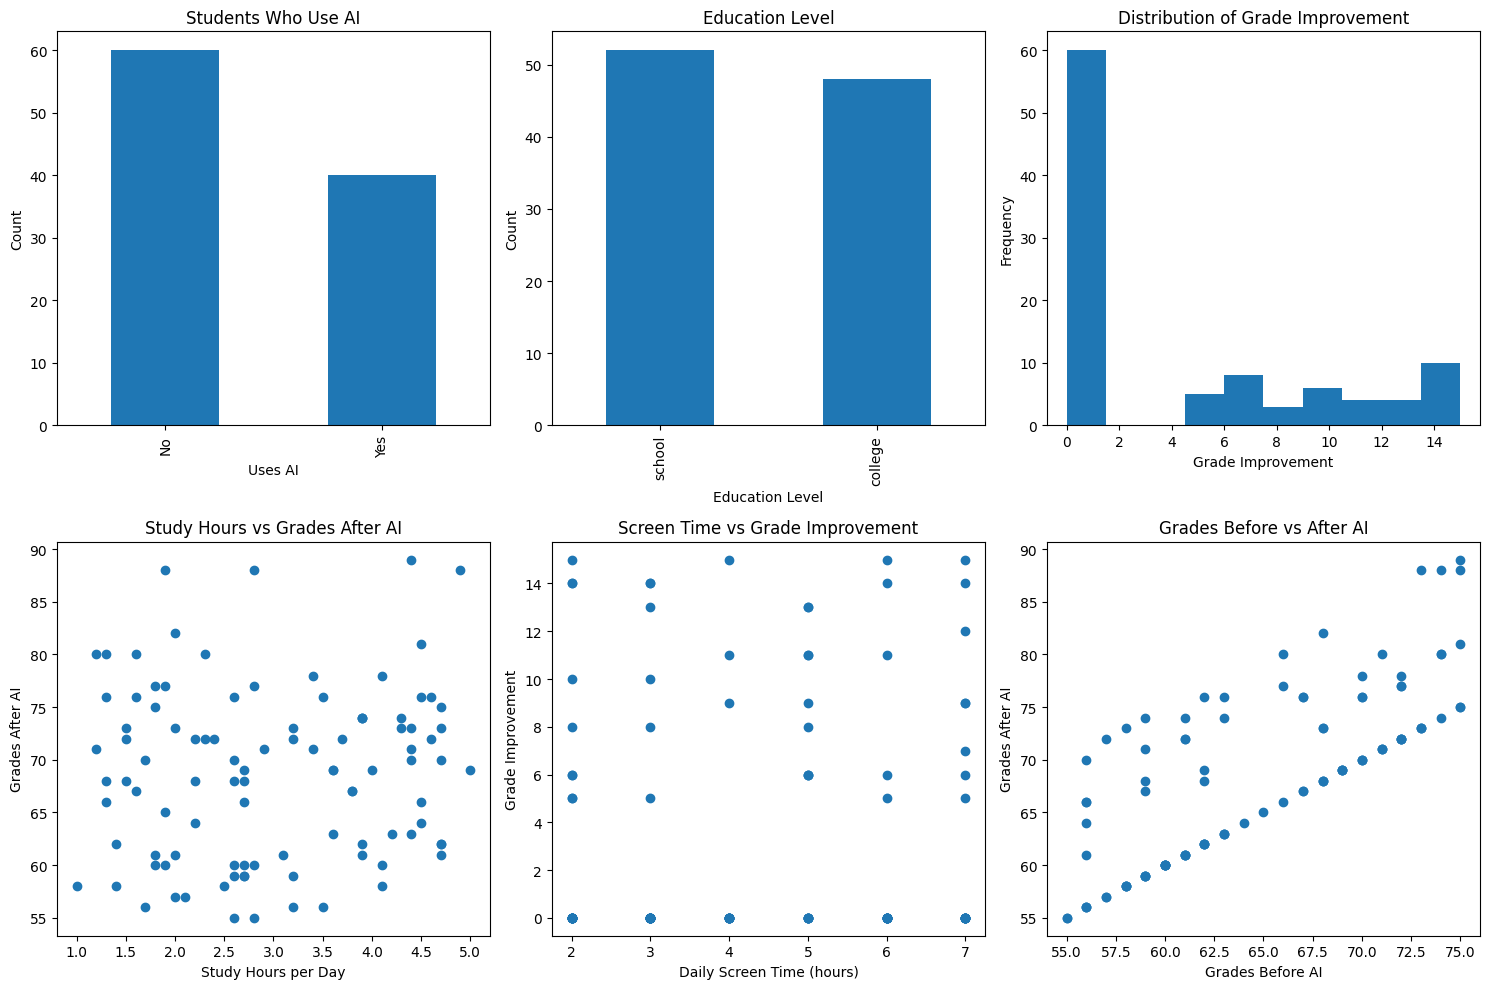

In [37]:
# =========================================================
# PART 6 — BASIC VISUALIZATIONS
# This section shows distributions and simple relationships
# in the dataset using bar charts, histograms, and scatter plots.
# Split here if you want section 6 to start.
# =========================================================

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
df["uses_ai"].value_counts().plot(kind="bar")
plt.title("Students Who Use AI")
plt.xlabel("Uses AI")
plt.ylabel("Count")

plt.subplot(2, 3, 2)
df["education_level"].value_counts().plot(kind="bar")
plt.title("Education Level")
plt.xlabel("Education Level")
plt.ylabel("Count")

plt.subplot(2, 3, 3)
plt.hist(df["grade_improvement"], bins=10)
plt.title("Distribution of Grade Improvement")
plt.xlabel("Grade Improvement")
plt.ylabel("Frequency")

plt.subplot(2, 3, 4)
plt.scatter(df["study_hours_per_day"], df["grades_after_ai"])
plt.title("Study Hours vs Grades After AI")
plt.xlabel("Study Hours per Day")
plt.ylabel("Grades After AI")

plt.subplot(2, 3, 5)
plt.scatter(df["daily_screen_time_hours"], df["grade_improvement"])
plt.title("Screen Time vs Grade Improvement")
plt.xlabel("Daily Screen Time (hours)")
plt.ylabel("Grade Improvement")

plt.subplot(2, 3, 6)
plt.scatter(df["grades_before_ai"], df["grades_after_ai"])
plt.title("Grades Before vs After AI")
plt.xlabel("Grades Before AI")
plt.ylabel("Grades After AI")

plt.tight_layout()
plt.show()


Average values for AI users and non-users:
         study_hours_per_day  grades_before_ai  grades_after_ai  \
uses_ai                                                           
No                  3.091667            64.400            64.40   
Yes                 2.830000            65.325            75.15   

         grade_improvement  daily_screen_time_hours  
uses_ai                                              
No                   0.000                    4.250  
Yes                  9.825                    4.475  


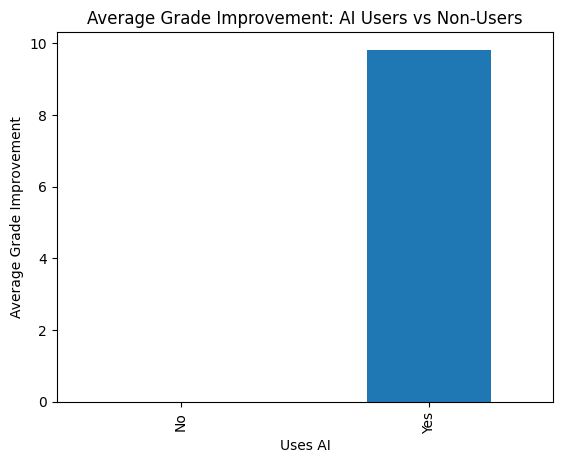

In [38]:
# =========================================================
# PART 7 — COMPARE AI USERS AND NON-USERS
# This section compares average study time, grades, screen time,
# and grade improvement between AI users and non-users.
# Split here if you want section 7 to start.
# =========================================================

group_means = df.groupby("uses_ai")[[
    "study_hours_per_day",
    "grades_before_ai",
    "grades_after_ai",
    "grade_improvement",
    "daily_screen_time_hours"
]].mean()

print("\nAverage values for AI users and non-users:")
print(group_means)

group_means["grade_improvement"].plot(kind="bar")
plt.title("Average Grade Improvement: AI Users vs Non-Users")
plt.xlabel("Uses AI")
plt.ylabel("Average Grade Improvement")
plt.show()


Average grade improvement by AI tool:
ai_tools_used
Gemini     10.846154
Copilot    10.000000
ChatGPT     8.615385
Name: grade_improvement, dtype: float64


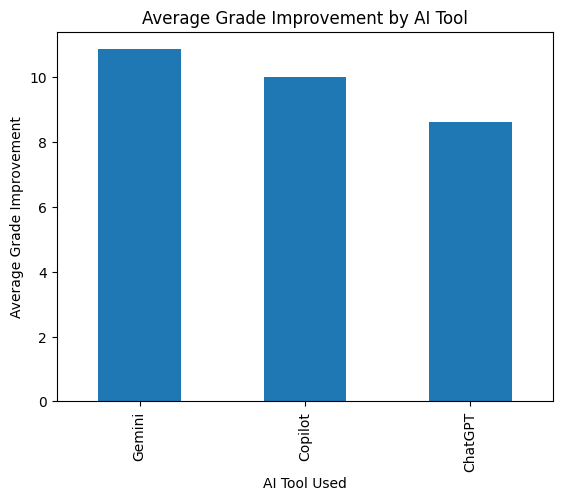

In [39]:
# =========================================================
# PART 8 — COMPARE AI TOOLS USED
# This section checks which AI tools are linked to the highest
# average grade improvement among students who use AI.
# Split here if you want section 8 to start.
# =========================================================

ai_users = df[df["uses_ai"] == "Yes"].copy()

tool_means = ai_users.groupby("ai_tools_used")["grade_improvement"].mean().sort_values(ascending=False)

print("\nAverage grade improvement by AI tool:")
print(tool_means)

tool_means.plot(kind="bar")
plt.title("Average Grade Improvement by AI Tool")
plt.xlabel("AI Tool Used")
plt.ylabel("Average Grade Improvement")
plt.show()


Average grade improvement by purpose of AI use:
purpose_of_ai
Research    10.285714
Coding      10.000000
Homework     9.153846
Name: grade_improvement, dtype: float64


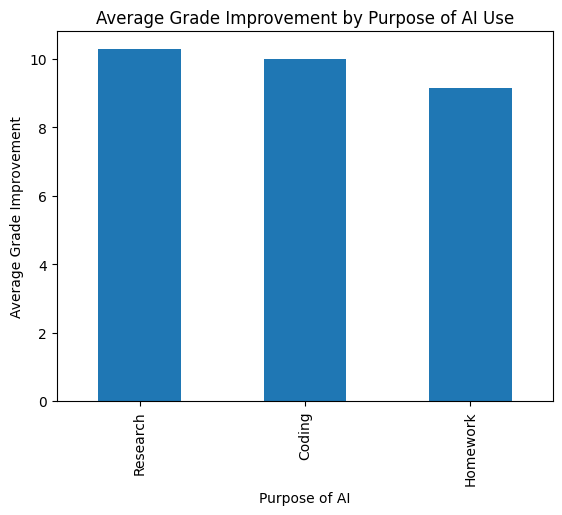

In [40]:
# =========================================================
# PART 9 — COMPARE PURPOSE OF AI USE
# This section checks whether using AI for homework, research,
# or coding is linked to different grade improvements.
# Split here if you want section 9 to start.
# =========================================================

purpose_means = ai_users.groupby("purpose_of_ai")["grade_improvement"].mean().sort_values(ascending=False)

print("\nAverage grade improvement by purpose of AI use:")
print(purpose_means)

purpose_means.plot(kind="bar")
plt.title("Average Grade Improvement by Purpose of AI Use")
plt.xlabel("Purpose of AI")
plt.ylabel("Average Grade Improvement")
plt.show()


Correlation matrix:
                              age  study_hours_per_day  grades_before_ai  \
age                      1.000000             0.010548         -0.099754   
study_hours_per_day      0.010548             1.000000          0.171210   
grades_before_ai        -0.099754             0.171210          1.000000   
grades_after_ai         -0.049774             0.075170          0.756268   
daily_screen_time_hours  0.259141            -0.026830          0.078349   
grade_improvement        0.039464            -0.083411         -0.002339   
uses_ai_binary          -0.019279            -0.112450          0.073826   

                         grades_after_ai  daily_screen_time_hours  \
age                            -0.049774                 0.259141   
study_hours_per_day             0.075170                -0.026830   
grades_before_ai                0.756268                 0.078349   
grades_after_ai                 1.000000                 0.095611   
daily_screen_time_hours  

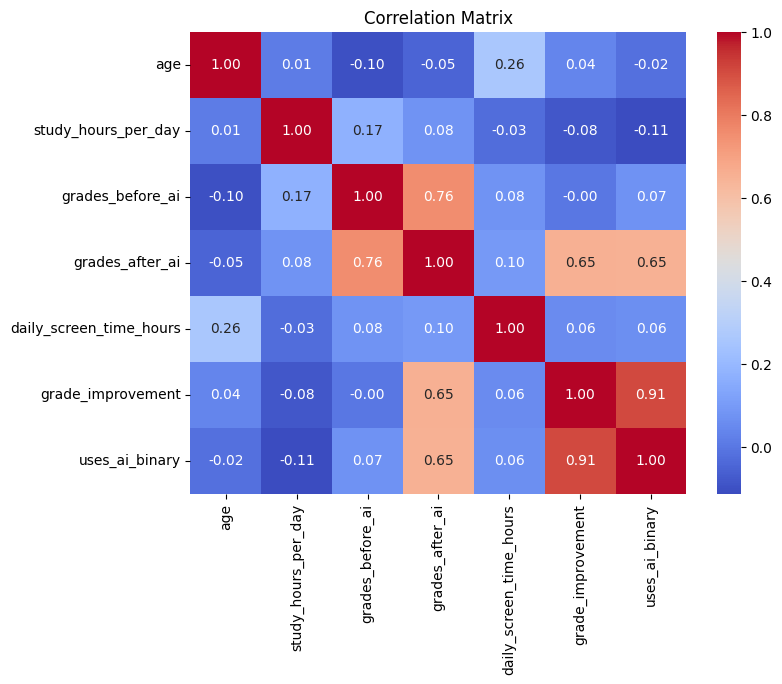

In [41]:
# =========================================================
# PART 10 — CORRELATION ANALYSIS
# This section calculates correlations between numeric variables
# and displays them in a heatmap.
# Split here if you want section 10 to start.
# =========================================================

corr_cols = [
    "age",
    "study_hours_per_day",
    "grades_before_ai",
    "grades_after_ai",
    "daily_screen_time_hours",
    "grade_improvement",
    "uses_ai_binary"
]

corr_matrix = df[corr_cols].corr()

print("\nCorrelation matrix:")
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [42]:
# =========================================================
# PART 11 — PREPROCESSING FOR PCA AND ICA
# This section prepares the data for transforms by:
# 1) scaling numeric features
# 2) one-hot encoding categorical features
# This satisfies the preprocessing requirement.
# Split here if you want section 11 to start.
# =========================================================

features = [
    "age",
    "education_level",
    "study_hours_per_day",
    "uses_ai",
    "ai_tools_used",
    "purpose_of_ai",
    "grades_before_ai",
    "grades_after_ai",
    "daily_screen_time_hours",
    "grade_improvement"
]

numeric_features = [
    "age",
    "study_hours_per_day",
    "grades_before_ai",
    "grades_after_ai",
    "daily_screen_time_hours",
    "grade_improvement"
]

categorical_features = [
    "education_level",
    "uses_ai",
    "ai_tools_used",
    "purpose_of_ai"
]

X = df[features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(X)
X_input = X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed

print("\nProcessed data shape:", X_input.shape)


Processed data shape: (100, 18)



Explained variance ratio of first 2 PCA components:
[0.33443057 0.19623357]
Total explained variance captured by first 2 components:
0.5306641448640748


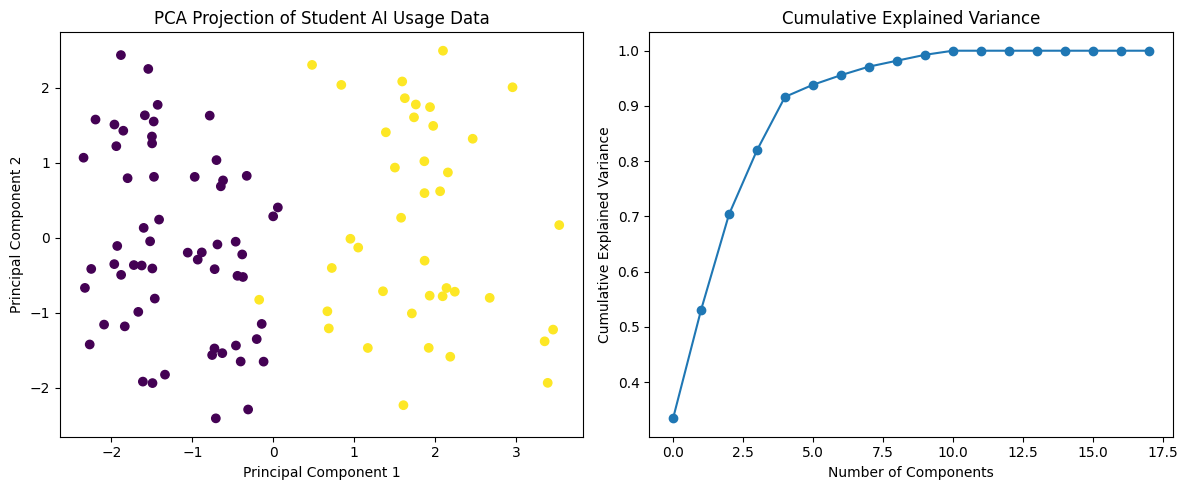

In [43]:
# =========================================================
# PART 12 — PCA ANALYSIS
# This section applies Principal Components Analysis to find
# the most informative low-dimensional representation.
# This satisfies the PCA requirement.
# Split here if you want section 12 to start.
# =========================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_input)

print("\nExplained variance ratio of first 2 PCA components:")
print(pca.explained_variance_ratio_)
print("Total explained variance captured by first 2 components:")
print(pca.explained_variance_ratio_.sum())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["uses_ai_binary"])
plt.title("PCA Projection of Student AI Usage Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.subplot(1, 2, 2)
pca_full = PCA()
pca_full.fit(X_input)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.tight_layout()
plt.show()

In [44]:
# =========================================================
# PART 13 — PCA FEATURE IMPORTANCE
# This section shows which original variables contribute most
# strongly to the principal components.
# Split here if you want section 13 to start.
# =========================================================

feature_names_num = numeric_features
feature_names_cat = preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features)
feature_names = np.concatenate([feature_names_num, feature_names_cat])

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca_full.components_))],
    index=feature_names
)

print("\nTop 10 strongest features for PC1:")
print(loadings["PC1"].sort_values(key=np.abs, ascending=False).head(10))

print("\nTop 10 strongest features for PC2:")
print(loadings["PC2"].sort_values(key=np.abs, ascending=False).head(10))


Top 10 strongest features for PC1:
grades_after_ai           0.552969
grade_improvement         0.532917
grades_before_ai          0.269598
uses_ai_No               -0.265681
uses_ai_Yes               0.265681
ai_tools_used_nan        -0.265681
purpose_of_ai_nan        -0.265681
ai_tools_used_Copilot     0.099423
purpose_of_ai_Research    0.096296
ai_tools_used_Gemini      0.089977
Name: PC1, dtype: float64

Top 10 strongest features for PC2:
age                        0.715611
daily_screen_time_hours    0.363779
education_level_school    -0.326027
education_level_college    0.326027
grades_before_ai          -0.291904
grades_after_ai           -0.137198
grade_improvement          0.128398
study_hours_per_day       -0.102029
ai_tools_used_Gemini       0.055825
purpose_of_ai_Research     0.042452
Name: PC2, dtype: float64



ICA output shape: (100, 2)


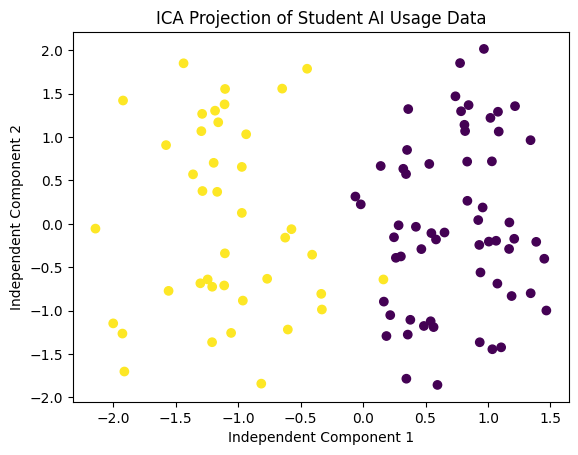

In [45]:
# =========================================================
# PART 14 — ICA ANALYSIS
# This section applies Independent Components Analysis to find
# hidden statistically independent patterns in the data.
# This satisfies the ICA requirement.
# Split here if you want section 14 to start.
# =========================================================

ica = FastICA(n_components=2, random_state=42)
X_ica = ica.fit_transform(X_input)

print("\nICA output shape:", X_ica.shape)

plt.scatter(X_ica[:, 0], X_ica[:, 1], c=df["uses_ai_binary"])
plt.title("ICA Projection of Student AI Usage Data")
plt.xlabel("Independent Component 1")
plt.ylabel("Independent Component 2")
plt.show()


Average values by education level:
                 study_hours_per_day  grades_before_ai  grades_after_ai  \
education_level                                                           
college                     3.052083         64.479167        68.916667   
school                      2.926923         65.038462        68.500000   

                 grade_improvement  daily_screen_time_hours  
education_level                                              
college                   4.437500                 4.625000  
school                    3.461538                 4.076923  


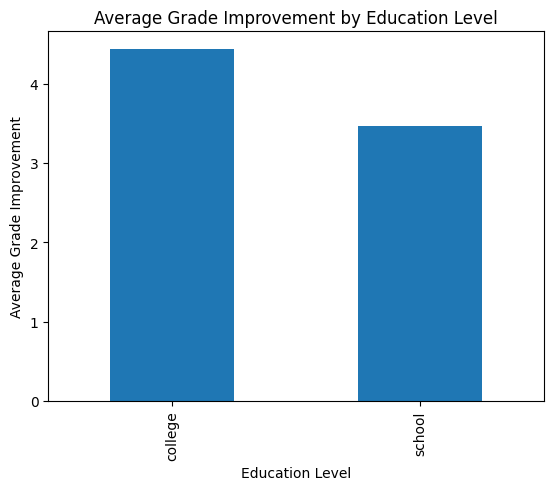

In [46]:
# =========================================================
# PART 15 — COMPARE SCHOOL AND COLLEGE STUDENTS
# This section checks whether education level is related to
# study time, grades, screen time, and improvement.
# Split here if you want section 15 to start.
# =========================================================

edu_means = df.groupby("education_level")[[
    "study_hours_per_day",
    "grades_before_ai",
    "grades_after_ai",
    "grade_improvement",
    "daily_screen_time_hours"
]].mean()

print("\nAverage values by education level:")
print(edu_means)

edu_means["grade_improvement"].plot(kind="bar")
plt.title("Average Grade Improvement by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Grade Improvement")
plt.show()


Number of AI users: 40

Preview of AI users:
   ai_tools_used purpose_of_ai  grade_improvement
1        Copilot      Research                  5
2        Copilot      Homework                 13
6        Copilot      Research                  6
8         Gemini      Homework                  6
11       ChatGPT      Research                  9


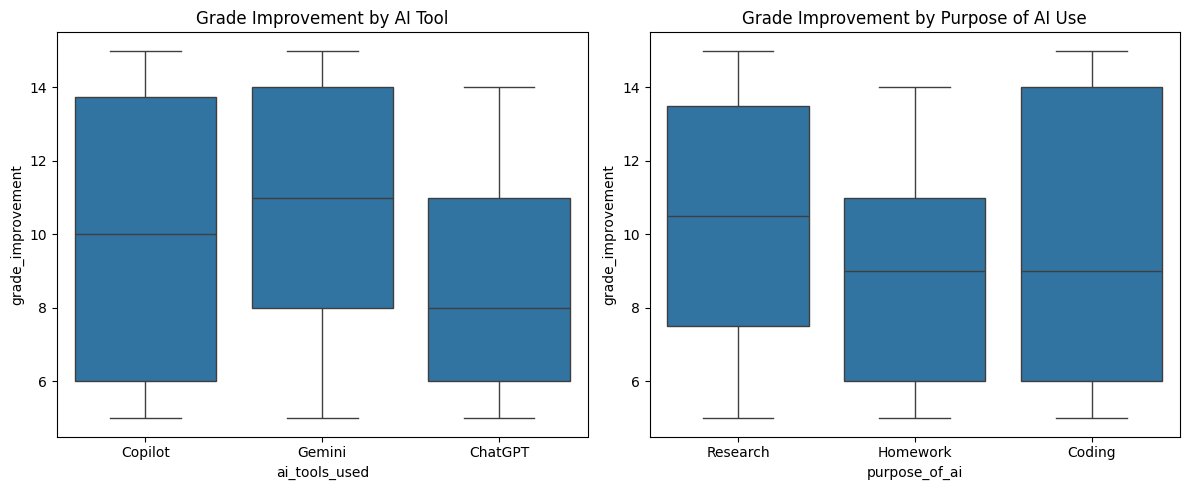

In [47]:
# =========================================================
# PART 16 — DEEPER ANALYSIS FOR AI USERS ONLY
# This section focuses only on students who use AI and compares
# grade improvement across tools and purposes.
# Split here if you want section 16 to start.
# =========================================================

print("\nNumber of AI users:", len(ai_users))
print("\nPreview of AI users:")
print(ai_users[["ai_tools_used", "purpose_of_ai", "grade_improvement"]].head())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=ai_users, x="ai_tools_used", y="grade_improvement")
plt.title("Grade Improvement by AI Tool")

plt.subplot(1, 2, 2)
sns.boxplot(data=ai_users, x="purpose_of_ai", y="grade_improvement")
plt.title("Grade Improvement by Purpose of AI Use")

plt.tight_layout()
plt.show()


Signal length: 100
First 20 values of the signal:
[ 0  5 13  0  0  0  6  0  6  0  0  9  0  0  0  0  0  6  6  0]


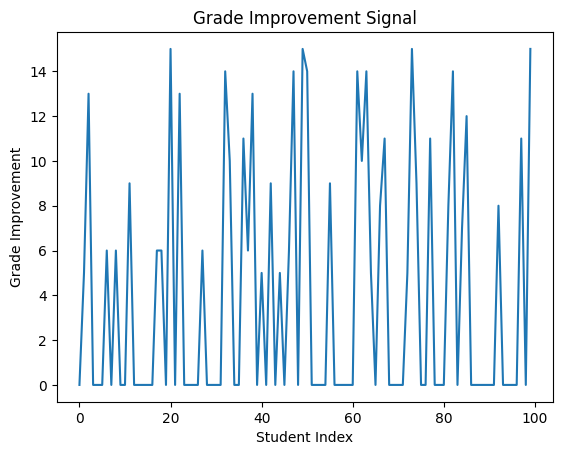

In [48]:
# =========================================================
# PART 17 — CREATE A SIGNAL FOR TRANSFORM DEMONSTRATIONS
# This section turns the grade_improvement column into a simple
# one-dimensional signal so that course transforms like FFT,
# spectrogram, wavelets, filters, sonification, and compressed
# sensing can be demonstrated.
# Note: this is only a demonstration because the dataset is not
# a true time series.
# Split here if you want section 17 to start.
# =========================================================

grade_signal = df["grade_improvement"].values

print("\nSignal length:", len(grade_signal))
print("First 20 values of the signal:")
print(grade_signal[:20])

plt.plot(grade_signal)
plt.title("Grade Improvement Signal")
plt.xlabel("Student Index")
plt.ylabel("Grade Improvement")
plt.show()

In [49]:
# =========================================================
# PART 18 — SONIFICATION
# This section converts the signal into sound so the data can
# be explored through audio.
# This satisfies the sonification requirement.
# Split here if you want section 18 to start.
# =========================================================

audio_signal = grade_signal.astype(float)
audio_signal = audio_signal - np.mean(audio_signal)
audio_signal = audio_signal / np.max(np.abs(audio_signal))

print("\nPlaying sonified grade improvement signal:")
display(Audio(audio_signal, rate=4000))


Playing sonified grade improvement signal:


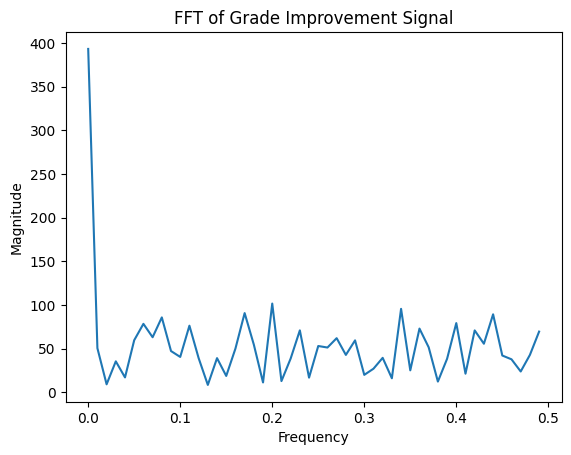

In [50]:
# =========================================================
# PART 19 — FFT
# This section applies the Fast Fourier Transform to the signal
# to show its frequency content.
# This satisfies the FFT requirement.
# Split here if you want section 19 to start.
# =========================================================

N = len(grade_signal)
fft_vals = fft(grade_signal)
freqs = fftfreq(N, d=1)

plt.plot(freqs[:N // 2], np.abs(fft_vals[:N // 2]))
plt.title("FFT of Grade Improvement Signal")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.show()

/var/folders/c6/ddtjcdbs0z51sxkqg02p46sh0000gn/T/ipykernel_3970/1084327556.py:9: UserWarning: Only one segment is calculated since parameter NFFT (=256) >= signal length (=100).
  plt.specgram(grade_signal, Fs=1, scale='linear')


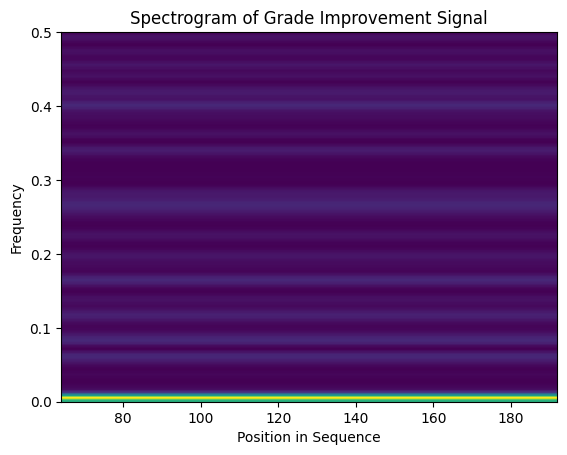

In [51]:
# =========================================================
# PART 20 — SPECTROGRAM
# This section plots a spectrogram to show how frequency
# content changes across the signal.
# This satisfies the spectrogram requirement.
# Split here if you want section 20 to start.
# =========================================================

plt.specgram(grade_signal, Fs=1, scale='linear')
plt.title("Spectrogram of Grade Improvement Signal")
plt.xlabel("Position in Sequence")
plt.ylabel("Frequency")
plt.show()

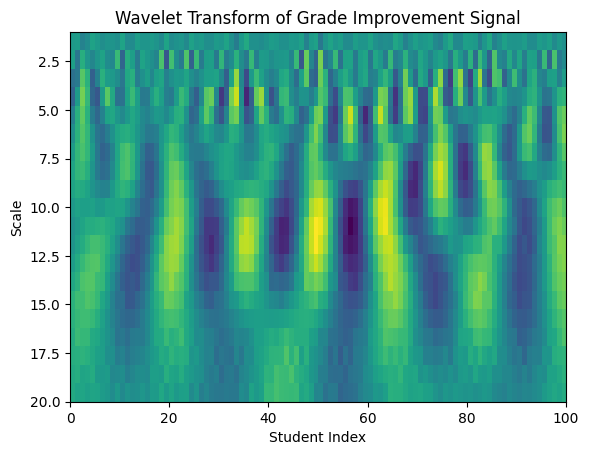

In [52]:
# =========================================================
# PART 21 — WAVELETS
# This section applies a wavelet transform to show localized
# patterns at different scales.
# This satisfies the wavelets requirement.
# Split here if you want section 21 to start.
# =========================================================

coeffs, freqs_wavelet = pywt.cwt(grade_signal, scales=np.arange(1, 21), wavelet='morl')

plt.imshow(coeffs, aspect='auto', cmap='viridis', extent=[0, len(grade_signal), 20, 1])
plt.title("Wavelet Transform of Grade Improvement Signal")
plt.xlabel("Student Index")
plt.ylabel("Scale")
plt.show()

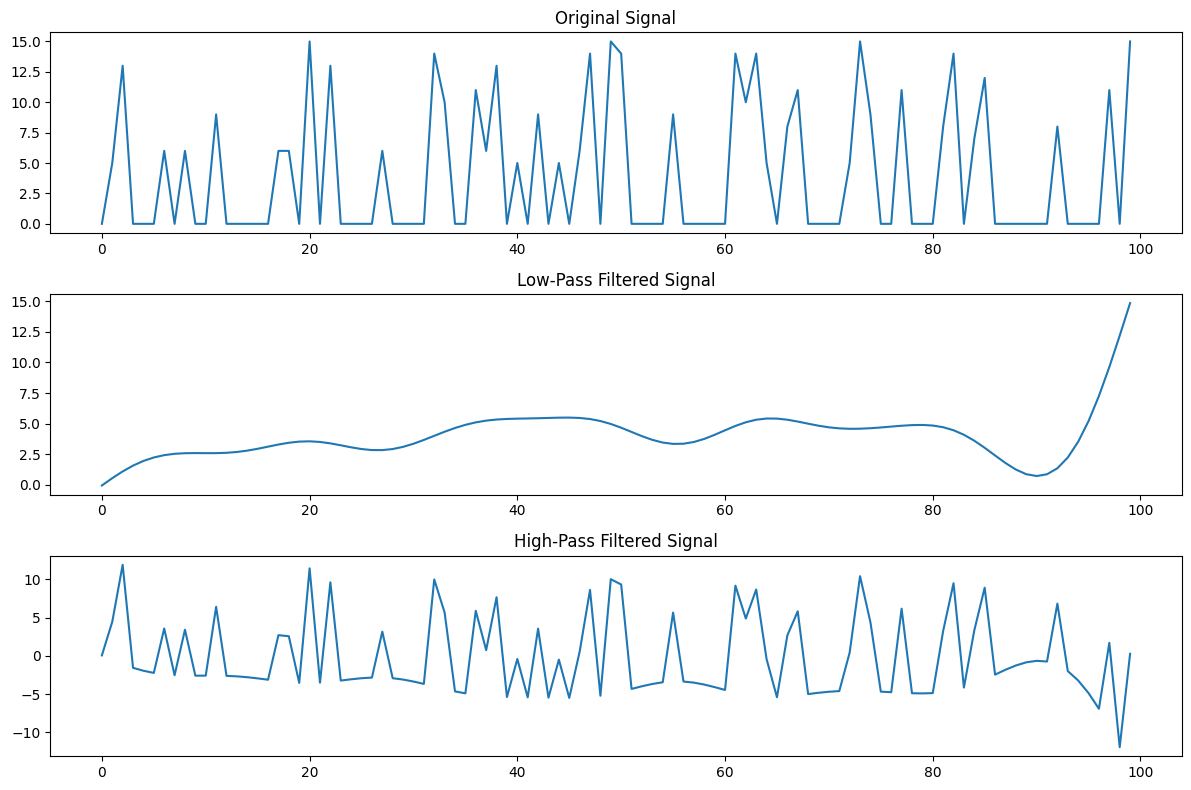

In [53]:
# =========================================================
# PART 22 — FILTERS
# This section applies low-pass and high-pass Butterworth
# filters to smooth the signal and isolate rapid changes.
# This satisfies the filters requirement.
# Split here if you want section 22 to start.
# =========================================================

signal = grade_signal.astype(float)

b_low, a_low = butter(3, 0.1, btype='low')
low_filtered = filtfilt(b_low, a_low, signal)

b_high, a_high = butter(3, 0.1, btype='high')
high_filtered = filtfilt(b_high, a_high, signal)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(signal)
plt.title("Original Signal")

plt.subplot(3, 1, 2)
plt.plot(low_filtered)
plt.title("Low-Pass Filtered Signal")

plt.subplot(3, 1, 3)
plt.plot(high_filtered)
plt.title("High-Pass Filtered Signal")

plt.tight_layout()
plt.show()

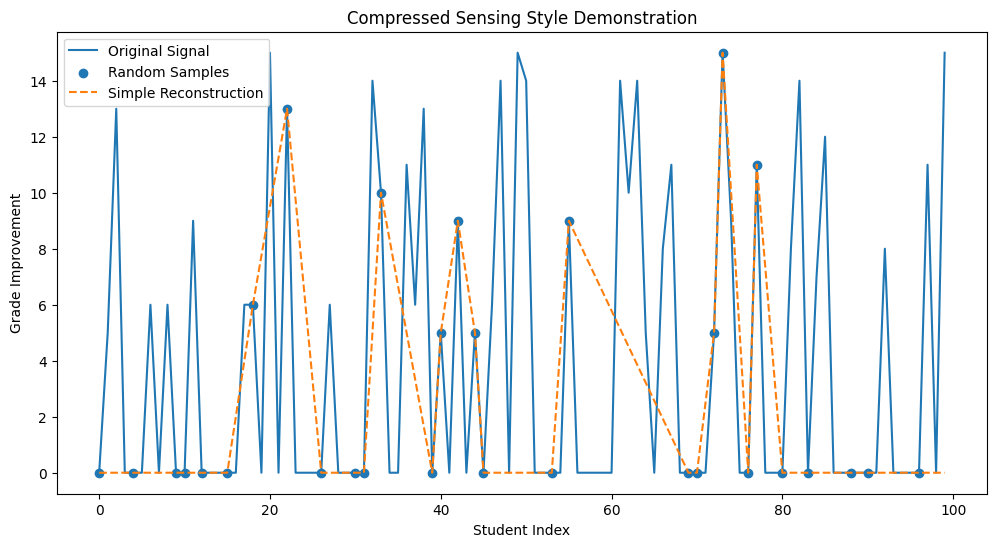

In [54]:
# =========================================================
# PART 23 — COMPRESSED SENSING STYLE DEMONSTRATION
# This section keeps only random parts of the signal and then
# reconstructs it with interpolation to demonstrate the idea
# of compressed sensing.
# This satisfies the compressed sensing requirement at a simple level.
# Split here if you want section 23 to start.
# =========================================================

signal = grade_signal.astype(float)
n = len(signal)

np.random.seed(42)
fraction = 0.3
sample_indices = np.sort(np.random.choice(np.arange(n), size=int(n * fraction), replace=False))
sampled_signal = np.full(n, np.nan)
sampled_signal[sample_indices] = signal[sample_indices]

reconstructed_signal = pd.Series(sampled_signal).interpolate().bfill().ffill().values

plt.figure(figsize=(12, 6))
plt.plot(signal, label="Original Signal")
plt.scatter(sample_indices, signal[sample_indices], label="Random Samples")
plt.plot(reconstructed_signal, label="Simple Reconstruction", linestyle="--")
plt.title("Compressed Sensing Style Demonstration")
plt.xlabel("Student Index")
plt.ylabel("Grade Improvement")
plt.legend()
plt.show()

In [55]:
### =========================================================
# PART 24 — FINAL NUMERICAL SUMMARY
# This section prints the main results of the notebook in a
# concise way for easy interpretation.
# Split here if you want section 24 to start.
# =========================================================

print("\nAverage grade improvement overall:", df["grade_improvement"].mean())
print("Average grade improvement for AI users:", df[df["uses_ai"] == "Yes"]["grade_improvement"].mean())
print("Average grade improvement for non-users:", df[df["uses_ai"] == "No"]["grade_improvement"].mean())

print("\nAverage grade improvement by AI tool:")
print(df[df["uses_ai"] == "Yes"].groupby("ai_tools_used")["grade_improvement"].mean())

print("\nAverage grade improvement by purpose:")
print(df[df["uses_ai"] == "Yes"].groupby("purpose_of_ai")["grade_improvement"].mean())

print("\nAverage grade improvement by education level:")
print(df.groupby("education_level")["grade_improvement"].mean())


Average grade improvement overall: 3.93
Average grade improvement for AI users: 9.825
Average grade improvement for non-users: 0.0

Average grade improvement by AI tool:
ai_tools_used
ChatGPT     8.615385
Copilot    10.000000
Gemini     10.846154
Name: grade_improvement, dtype: float64

Average grade improvement by purpose:
purpose_of_ai
Coding      10.000000
Homework     9.153846
Research    10.285714
Name: grade_improvement, dtype: float64

Average grade improvement by education level:
education_level
college    4.437500
school     3.461538
Name: grade_improvement, dtype: float64
